# 06a · Analysing a trained RL agent

This companion notebook takes the run written by **06 · Training a PPO agent** and
performs a deeper post-hoc analysis:

1. **Checkpoint loading** — load the self-describing bundle and validate the layout
   version; fail loudly on mismatch rather than silently with a shape error.
2. **Training trajectory** — read every eval-cadence scalar to reconstruct the full
   learning curve and select the best checkpoint by `eval/paired_uplift`.
3. **Variable-K inference** — run the same `SetActor` checkpoint at K=2 and K=5 to
   confirm it generalises without retraining.
4. **Deep CRN comparison** — step through one full episode side-by-side (RL vs a naive
   constant policy) to see how the gap accumulates tick by tick.
5. **Regime analysis** — stratify per-seed results by K value to see where the policy
   gains or loses; **5b** stress-tests the capacity-starved regime hypothesised to
   favour the RL agent (spoiler: the baseline still wins there); **5c** compares the
   proportional- and greedy-Arbiter training runs.
6. **Implicit assortment** — show which products the policy allocates budget to (implicit
   assortment selection via the order-up-to head; price and priority heads alongside).
7. **Permutation equivariance** — verify the shared-weight actor's distribution means
   permute in kind when product rows are permuted.
8. **Attach-and-run demo** — attach the best proportional checkpoint to a node via
   `RLNodePolicy.from_checkpoint` + `policy_overrides` + `Runner.run()`, then analyse the
   run log; re-run the same attach recipe on a second world (same degenerate topology) to
   show the API composes with any Runner-compatible scenario (OOD caveat noted).

**Eval parity.** The offline eval harness (`src/rl/eval.py`) runs both the RL arm and the
baseline arm through the identical `Runner.run()` engine code path — the same path the RL
agent trained on. The Arbiter is applied inside `RLNodePolicy.decide()`, so train and eval
share one code path (ADR 0022). The `eval/*` TensorBoard scalars recorded before this fix
(in the `_fixed`/`_greedy` runs) used the old arbiter-less eval path — and that path was
not just different, it was **unfairly favourable to the RL arm**: `decode_set_action` caps
orders only per SKU, and the engine's capacity clamp ignores in-transit (pending) stock,
so without the Arbiter the joint order across K≈16 SKUs could stack pending deliveries to
~10–16× the node capacity. The previously reported "RL wins the capacity-starved regime"
numbers came entirely from that capacity violation. The fresh evals in this notebook are
the corrected, parity-correct numbers — and they are less flattering.

**The two runs analysed here.** Both were trained with the same bug-fixed code and the
same seed; they differ in exactly one flag, the Arbiter allocation mode:

| Run directory | Arbiter | Note |
|---|---|---|
| `runs/fashion_run_fixed` | `proportional` (default) | "fixed" means *bug-fixed*, not an arbiter type |
| `runs/fashion_run_greedy` | `greedy` | trained with `--arbiter-mode greedy` |

Sections 0–5b analyse the proportional run; section 5c loads the greedy run and
compares the two.

In [1]:
%matplotlib inline
import os
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 90
print('cwd:', Path.cwd())

cwd: /workspace/.claude/worktrees/issue-04-notebook-06a-rewrite


## 0 · Point at the run produced by notebook 06

We reference the same run directory that notebook 06 wrote to. Re-run that notebook
first if the directory is missing.

In [2]:
# RUN_ROOT = Path('data/notebook_demos/06/runs')
# EXPERIMENT = 'nb06_demo'
RUN_ROOT = Path('runs')
EXPERIMENT = 'fashion_run_fixed'
run_dir = RUN_ROOT / EXPERIMENT
ckpt_dir = run_dir / 'checkpoints'

assert run_dir.exists(), f'Run dir missing: {run_dir} — run notebook 06 first'
assert ckpt_dir.exists(), f'Checkpoint dir missing: {ckpt_dir}'

ckpts = sorted(ckpt_dir.glob('actor_step*.pt'))
print(f'Run dir:  {run_dir}')
print(f'Checkpoints found: {len(ckpts)}')
for p in ckpts:
    print(f'  {p.name}')

Run dir:  runs/fashion_run_fixed
Checkpoints found: 20
  actor_step0000050176.pt
  actor_step0000100352.pt
  actor_step0000150528.pt
  actor_step0000200704.pt
  actor_step0000250880.pt
  actor_step0000300032.pt
  actor_step0000350208.pt
  actor_step0000400384.pt
  actor_step0000450560.pt
  actor_step0000500736.pt
  actor_step0000550912.pt
  actor_step0000600064.pt
  actor_step0000650240.pt
  actor_step0000700416.pt
  actor_step0000750592.pt
  actor_step0000800768.pt
  actor_step0000850944.pt
  actor_step0000900096.pt
  actor_step0000950272.pt
  actor_step0001000000.pt


## 1 · Load a checkpoint and validate layout version

`checkpoint.load()` raises `ValueError` if `layout_version` in the bundle does not match
`OBS_LAYOUT_VERSION` from `set_encoder.py`. This is the first line of defence against
loading a checkpoint trained on an incompatible observation layout.

In [3]:
from src.rl.checkpoint import load as ckpt_load
from src.rl.set_encoder import K_MAX, F, ROW_MASK, OBS_LAYOUT_VERSION
from src.rl.agents.set_actor_critic import SetActor

def load_actor(ckpt_path: Path) -> tuple:
    bundle = ckpt_load(ckpt_path)   # raises ValueError on layout_version mismatch
    actor = SetActor()
    actor.load_state_dict(bundle['state_dict'])
    actor.eval()
    return actor, bundle

latest_actor, latest_bundle = load_actor(ckpts[-1])
print(f'Loaded: {ckpts[-1].name}')
print(f'  layout_version: {latest_bundle["layout_version"]}  '
      f'(current: {OBS_LAYOUT_VERSION}) ✓')
print(f'  saved K_max_episode: {latest_bundle["config"].get("K_max_episode", "?")}',
      f'  K_catalog: {latest_bundle["config"].get("K_catalog", "?")}',
      f'  arbiter_mode: {latest_bundle["config"].get("arbiter_mode", "proportional")}')
print(f'  state_dict tensors: {len(latest_bundle["state_dict"])}')

Loaded: actor_step0001000000.pt
  layout_version: 1  (current: 1) ✓
  saved K_max_episode: 20   K_catalog: 100   arbiter_mode: proportional
  state_dict tensors: 7


## 2 · Training trajectory and model selection

We read every `eval/paired_uplift` scalar from the TensorBoard event file and pick the
checkpoint with the highest uplift as the best model. For a real run you would also look
at confidence intervals and variance, but for the demo we take the argmax. Note that the
uplift curve never crosses zero on this run: "best checkpoint" means *least bad relative
to the baseline*, not "beats the baseline" — the selection logic is the same either way.

**Why the baseline line is flat.** The eval harness uses a *fixed* set of held-out CRN
seeds (`eval_seed_offset = 10 000 000`, never seen in training), and `OrderUpToPolicy`
is deterministic given a seed. Every eval cadence therefore re-runs the identical
baseline on identical worlds and gets the identical mean return. This is intentional —
it is the Common-Random-Numbers property that makes `eval/paired_uplift` attributable
to the policy alone — and it doubles as a sanity check: **if the baseline line ever
moves, the CRN pairing is broken.** Only the RL line should change as the weights
change.

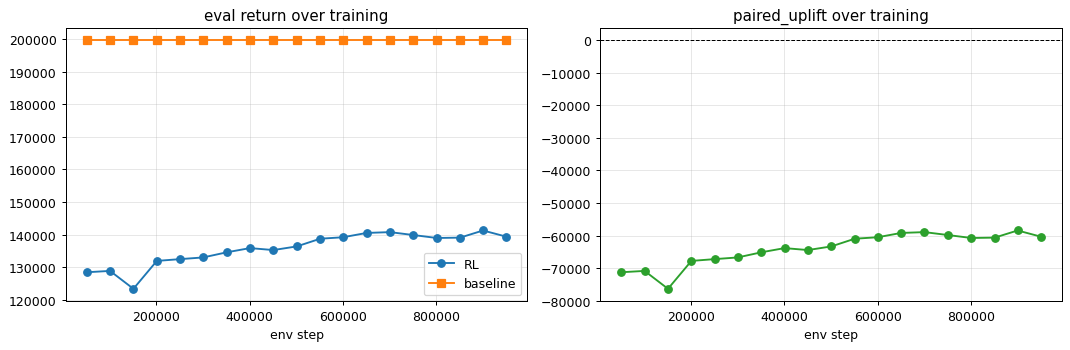

Best eval step by paired_uplift: 900096  (uplift=-58449.3)
  Using checkpoint: actor_step0000900096.pt


In [4]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

event_files = sorted(run_dir.glob('events.out.tfevents.*'))
assert event_files, 'No TensorBoard event files found'

ea = EventAccumulator(str(event_files[0]))
ea.Reload()
scalar_tags = ea.Tags()['scalars']

def scalar_series(tag):
    if tag not in scalar_tags: return [], []
    evs = ea.Scalars(tag)
    return [e.step for e in evs], [e.value for e in evs]

steps_up, vals_up   = scalar_series('eval/paired_uplift')
steps_rl, vals_rl   = scalar_series('eval/rl_return')
steps_bl, vals_bl   = scalar_series('eval/baseline_return')
steps_wr, vals_wr   = scalar_series('eval/win_rate')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if vals_rl:  axes[0].plot(steps_rl, vals_rl, marker='o', label='RL')
if vals_bl:  axes[0].plot(steps_bl, vals_bl, marker='s', label='baseline')
axes[0].set_title('eval return over training'); axes[0].set_xlabel('env step')
axes[0].legend(); axes[0].grid(alpha=0.3)

if vals_up:
    axes[1].plot(steps_up, vals_up, marker='o', color='C2')
    axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_title('paired_uplift over training'); axes[1].set_xlabel('env step')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

if vals_up and len(ckpts) > 1:
    best_idx = int(np.argmax(vals_up))
    best_step = steps_up[best_idx]
    print(f'Best eval step by paired_uplift: {best_step}  (uplift={vals_up[best_idx]:+.1f})')
    # Try to match to a checkpoint by step number in filename
    matching = [p for p in ckpts if str(best_step) in p.stem]
    best_ckpt = matching[0] if matching else ckpts[-1]
    print(f'  Using checkpoint: {best_ckpt.name}')
else:
    best_ckpt = ckpts[-1]
    print(f'Only one checkpoint or no eval/paired_uplift data. Using: {best_ckpt.name}')

best_actor, best_bundle = load_actor(best_ckpt)

## 3 · Variable-K inference: same weights, different K

Because `SetActor` applies the same per-row MLP to active rows and ignores padded rows
(mask=0), the same checkpoint works for any K from 1 to `K_MAX`. We construct synthetic
observations at K=2 and K=5, extract the mask, and call `get_action_and_log_prob` with
both to verify the outputs differ only in the active rows.

In [5]:
def make_fake_obs(k_active: int) -> tuple:
    """Return (obs_flat, obs_2d, mask_t) for a synthetic all-zero observation
    with k_active rows set to mask=1 and some non-trivial feature values."""
    obs_2d = np.zeros((K_MAX, F), dtype=np.float32)
    # Fill active rows with random-ish values
    rng = np.random.default_rng(k_active)
    obs_2d[:k_active, :] = rng.standard_normal((k_active, F)).astype(np.float32) * 0.3
    obs_2d[:k_active, ROW_MASK] = 1.0   # activate rows
    obs_flat = obs_2d.reshape(-1)
    obs_t  = torch.tensor(obs_2d, dtype=torch.float32).unsqueeze(0)  # (1, K_MAX, F)
    mask_t = torch.tensor(obs_2d[:, ROW_MASK], dtype=torch.float32).unsqueeze(0)  # (1, K_MAX)
    return obs_flat, obs_2d, obs_t, mask_t

print('Inference with the SAME checkpoint at different K values\n')
for k in [2, 5]:
    obs_flat, obs_2d, obs_t, mask_t = make_fake_obs(k)
    with torch.no_grad():
        action, logp, entropy = best_actor.get_action_and_log_prob(obs_t, mask_t)
    action_np = action.squeeze(0).numpy()  # (K_MAX, 3)
    print(f'K={k}: action shape={action_np.shape}')
    print(f'  active action rows [0..{k-1}]:')
    for r in range(k):
        print(f'    row {r}: {action_np[r].round(3).tolist()}')
    print(f'  padded action row [{k}]: {action_np[k].round(3).tolist()}  (ignored by Arbiter)')
    print(f'  log_prob={logp.item():.4f}, entropy={entropy.item():.4f}')
    print()

Inference with the SAME checkpoint at different K values

K=2: action shape=(32, 3)
  active action rows [0..1]:
    row 0: [0.7409999966621399, 0.5109999775886536, 0.9300000071525574]
    row 1: [-0.8259999752044678, 0.3199999928474426, -0.6169999837875366]
  padded action row [2]: [-0.0, 0.0, -0.0]  (ignored by Arbiter)
  log_prob=-3.8071, entropy=8.4449

K=5: action shape=(32, 3)
  active action rows [0..4]:
    row 0: [0.8529999852180481, -0.15600000321865082, -0.6179999709129333]
    row 1: [-0.7450000047683716, -0.7490000128746033, 0.32899999618530273]
    row 2: [-0.9589999914169312, -0.05700000002980232, 0.46399998664855957]
    row 3: [-0.8610000014305115, 0.7419999837875366, -0.9729999899864197]
    row 4: [-0.9559999704360962, 0.43299999833106995, 0.6240000128746033]
  padded action row [5]: [-0.0, 0.0, 0.0]  (ignored by Arbiter)
  log_prob=-9.1495, entropy=21.1122



## 4 · Deep CRN comparison: step-by-step episode

We run one full episode with the RL agent and a reference policy on the **same CRN seed**
(same world seed, capacity, balance, active_subset, allocation_sub_seed) and log the
step-by-step cumulative return to see where the gap accumulates. The policy_fn receives
a flat `(K_MAX * F,)` obs and returns a flat `(K_MAX * 3,)` action.

**Read this plot with three caveats** — it is illustrative, not evidence of beating the
textbook baseline:

1. **It is a single episode**, not an aggregate. Per-seed variance is large; the
   aggregate, held-out comparison is sections 5 and 5b.
2. **Seed 7 is from the training distribution.** Training envs are seeded 0–7 at start,
   so this exact world was plausibly seen during training. It is *not* one of the
   held-out eval seeds (those live at offset 10 000 000+).
3. **The reference policy here is NOT `OrderUpToPolicy`.** Both policies must run inside
   `RLEnv` to share the same two-phase tick path, so the reference is a naive constant
   policy expressed in the RL action space (all-zero raw actions → price = 1.0 × MSRP,
   order-up-to target held at the decoder centre). The real `OrderUpToPolicy` comparison
   runs through `evaluate()` in section 5.

The checkpoint used is the best one from `fashion_run_fixed` — i.e. the
**proportional**-Arbiter model.

Seed 7: K_active=6, episode_length=180
  RL total return:       +126442.5
  Baseline total return: +120102.2
  Uplift: +6340.3


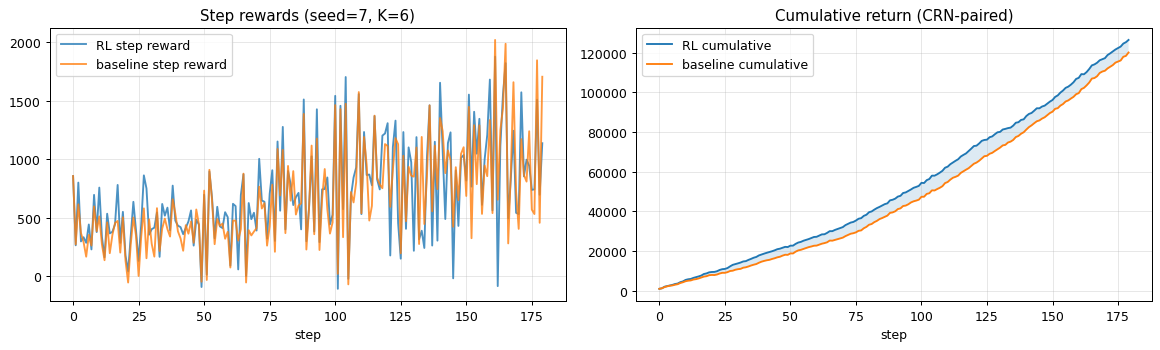

In [6]:
from src.rl.configs.default import RLConfig
from src.rl.episode_sampler import load_catalog_and_market_from_setup
from src.rl.env import RLEnv
from src.sim.policy import OrderUpToPolicy

saved_cfg = best_bundle['config']
cfg = RLConfig(
    K_min=saved_cfg.get('K_min', 1),
    K_max_episode=saved_cfg.get('K_max_episode', 5),
    K_catalog=saved_cfg.get('K_catalog', 12),
    episode_length=saved_cfg.get('episode_length', 30),
    arbiter_mode=saved_cfg.get('arbiter_mode', 'proportional'),
    cash_budget_fraction=saved_cfg.get('cash_budget_fraction', 1.0),
)

# Evaluate on the same world the agent was trained on: the fashion_retail
# setup (catalog + market). A synthetic catalog here would measure transfer
# to a different world, not the quality of this training run.
catalog, market = load_catalog_and_market_from_setup('setups/fashion_retail')

def rl_policy_fn(obs_flat: np.ndarray) -> np.ndarray:
    """obs_flat: flat (K_MAX * F,); returns flat (K_MAX * 3,)."""
    obs_2d = torch.tensor(obs_flat, dtype=torch.float32).reshape(1, K_MAX, F)
    mask   = obs_2d[..., ROW_MASK]  # (1, K_MAX)
    with torch.no_grad():
        action, _, _ = best_actor.get_action_and_log_prob(obs_2d, mask)
    return action.squeeze(0).reshape(K_MAX * 3).numpy()

SEED = 7

def run_episode(policy_fn, seed):
    env = RLEnv(catalog=catalog, config=cfg, market_params=market)
    obs_flat, info = env.reset(seed=seed)
    k_active = int(obs_flat.reshape(K_MAX, F)[:, ROW_MASK].sum())
    returns = []
    done = False
    while not done:
        action = policy_fn(obs_flat)
        obs_flat, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        returns.append(reward)
    return np.array(returns), k_active

def baseline_policy_fn(obs_flat: np.ndarray) -> np.ndarray:
    # Naive constant policy expressed in the RL action space: all-zero raw
    # actions decode to price = 1.0 x MSRP (col 0) and the order-up-to target
    # held at the decoder centre (col 1). Col 2 is the priority scalar, used
    # only by the greedy Arbiter. (The real OrderUpToPolicy comparison runs
    # through evaluate() in the next section.)
    return np.zeros(K_MAX * 3, dtype=np.float32)

rl_returns, k_active = run_episode(rl_policy_fn, seed=SEED)
bl_returns, _ = run_episode(baseline_policy_fn, seed=SEED)

rl_cum = np.cumsum(rl_returns)
bl_cum = np.cumsum(bl_returns)

print(f'Seed {SEED}: K_active={k_active}, episode_length={len(rl_returns)}')
print(f'  RL total return:       {rl_cum[-1]:+.1f}')
print(f'  Baseline total return: {bl_cum[-1]:+.1f}')
print(f'  Uplift: {rl_cum[-1] - bl_cum[-1]:+.1f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(rl_returns, label='RL step reward', alpha=0.8)
axes[0].plot(bl_returns, label='baseline step reward', alpha=0.8)
axes[0].set_title(f'Step rewards (seed={SEED}, K={k_active})')
axes[0].set_xlabel('step'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rl_cum, label='RL cumulative')
axes[1].plot(bl_cum, label='baseline cumulative')
axes[1].fill_between(range(len(rl_cum)), rl_cum, bl_cum, alpha=0.15)
axes[1].set_title('Cumulative return (CRN-paired)')
axes[1].set_xlabel('step'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5 · Regime analysis: stratify by K

This is the first *real* baseline comparison in the notebook: `evaluate()` runs the RL
policy and a fresh `OrderUpToPolicy` on the same **held-out** CRN seeds (offset
10 000 000+, never seen in training) and reports the paired uplift per seed. We
stratify the results by the K drawn for each episode to see whether variable-K training
produces a policy that is consistent across assortment sizes or degrades for extreme
values of K.

Expect mostly negative uplifts here: the seeds span the full domain-randomisation range
(capacity 100–10 000, balance 10 000–1 000 000), and when capacity is loose a per-SKU
order-up-to baseline is near-optimal — at a 1 M-step training budget the agent has not
caught it. Section 5b stress-tests the capacity-starved corner of this range, where the
baseline's blindness to the shared capacity pool was hypothesised to hurt it most.

**Why one seed shows an uplift of exactly 0.00.** The episode sampler sets initial
inventory to `capacity // K`; when the sampled capacity is large relative to total
episode demand, the node starts so over-stocked that `max(0, target·rate − position)`
is zero for *every* possible action — neither arm ever places an order, and prices are
inert engine-side (see section 6). Both arms then produce bit-identical runs, so the
paired uplift is exactly 0.0. Such "dead seeds" measure nothing about the policy; they
are an episode-design artifact.

,K_active,rl_return,baseline_return,uplift
seed_idx,,,,
0,3,43807.90,43807.90,0.00
1,2,58271.46,79655.37,-21383.91
2,10,121874.82,168545.33,-46670.51
3,13,87995.26,120893.78,-32898.52
4,16,58055.79,112014.12,-53958.33
5,18,48066.40,67542.11,-19475.71
6,11,275599.29,357482.87,-81883.58
7,12,12617.90,35018.80,-22400.90


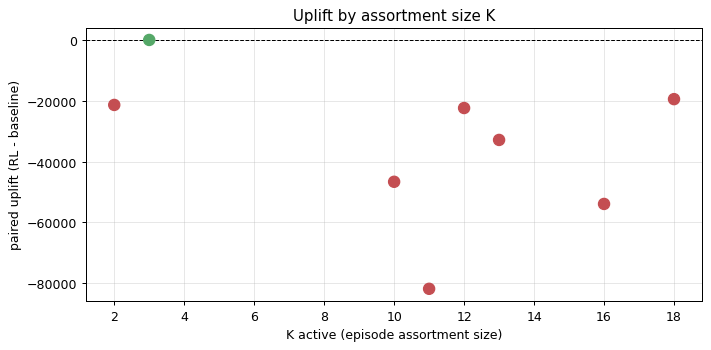

In [7]:
from src.rl.eval import build_eval_seeds, evaluate

N_SEEDS = 8
eval_specs = build_eval_seeds(catalog, cfg, n_seeds=N_SEEDS, market_params=market)

regime_rows = []
for i, spec in enumerate(eval_specs):
    env = RLEnv(catalog=catalog, config=cfg, market_params=market)
    obs_flat, info = env.reset(seed=spec.world_seed)
    k_active = int(obs_flat.reshape(K_MAX, F)[:, ROW_MASK].sum())
    m = evaluate(rl_policy_fn, lambda: OrderUpToPolicy(), [spec], config=cfg)
    regime_rows.append({
        'seed_idx': i,
        'K_active': k_active,
        'rl_return': m['eval/rl_return'],
        'baseline_return': m['eval/baseline_return'],
        'uplift': m['eval/paired_uplift'],
    })

regime_df = pd.DataFrame(regime_rows)
display(regime_df.set_index('seed_idx').round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(regime_df['K_active'], regime_df['uplift'],
                c=['#55A868' if u >= 0 else '#C44E52' for u in regime_df['uplift']],
                s=80, zorder=3)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('K active (episode assortment size)')
ax.set_ylabel('paired uplift (RL - baseline)')
ax.set_title('Uplift by assortment size K')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5b · Stress-testing the capacity-starved regime

The hypothesis: contention should favour the RL agent. `OrderUpToPolicy` computes a
per-SKU order-up-to target with no notion of the shared capacity pool; when ~15–20 SKUs
compete for ~100–150 units of capacity (5–10 units of shelf per product), its targets
jointly don't fit. The RL agent sees the contention features (`ROW_CONTENTION_QTY/COST`)
and could learn a joint allocation instead.

We test that precisely: fresh held-out CRN seeds with `K ∈ [15, 20]` and
`capacity ~ LogUniform(100, 150)`, paired against the same baseline on identical worlds.

**The result refutes the hypothesis at this training budget**: under the parity-correct
harness the baseline wins on every one of the 16 seeds (mean uplift −37.5 k, win rate
0.00). The agent does achieve a lower stockout rate (0.176 vs 0.244) — it spreads orders
across SKUs more evenly — but converts that into less profit, not more.

**Why earlier versions of this section claimed RL wins here.** The pre-rebuild eval path
ran the RL arm *without* the Arbiter. `decode_set_action` caps each SKU's order only
against that SKU's headroom (`capacity − inv − pending` per product), so the joint order
across ~16 SKUs could total many times the capacity; and the engine's own clamp ignores
in-transit (pending) stock and is not decremented across multiple order lines within a
tick, so nothing downstream stopped it. Measured on these very specs, the old path let
the RL node hold 10–16× its capacity. The baseline ran identically under both harnesses
(per-seed returns bit-identical), so the previously reported "+64 k mean uplift, 94 % win
rate" was entirely a capacity violation, not a policy skill.

,K,capacity,rl_return,baseline_return,uplift,rl_stockout,bl_stockout
seed,,,,,,,
0,15,136,96019.50,130998.90,-34979.40,0.18,0.19
1,16,118,93417.26,126055.06,-32637.80,0.20,0.23
2,19,103,40993.28,78149.48,-37156.20,0.19,0.31
3,16,101,63028.24,107723.89,-44695.65,0.14,0.27
4,16,125,97726.61,131347.63,-33621.02,0.14,0.22
5,15,108,91241.79,132117.40,-40875.61,0.14,0.24
6,18,119,94012.55,134391.62,-40379.07,0.17,0.24
7,15,122,115797.75,153087.80,-37290.05,0.15,0.22
8,19,131,125824.14,167345.87,-41521.73,0.17,0.25


mean paired uplift: -37529.0  (SE 1240.4)
win rate: 0.00
mean stockout: RL 0.176 vs baseline 0.244


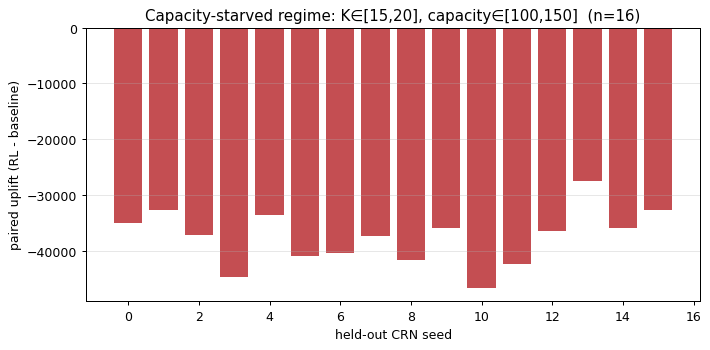

In [8]:
from src.sim.distributions import LogUniform

starved_cfg = RLConfig(
    K_min=15,
    K_max_episode=20,
    K_catalog=cfg.K_catalog,
    episode_length=cfg.episode_length,
    arbiter_mode=cfg.arbiter_mode,
    cash_budget_fraction=cfg.cash_budget_fraction,
    capacity_dist=LogUniform(100, 150),
)

N_STARVED_SEEDS = 16
starved_specs = build_eval_seeds(catalog, starved_cfg, n_seeds=N_STARVED_SEEDS, market_params=market)

starved_rows = []
for i, spec in enumerate(starved_specs):
    m = evaluate(rl_policy_fn, lambda: OrderUpToPolicy(), [spec], config=starved_cfg)
    starved_rows.append({
        'seed': i,
        'K': len(spec.active_subset),
        'capacity': spec.capacity,
        'rl_return': m['eval/rl_return'],
        'baseline_return': m['eval/baseline_return'],
        'uplift': m['eval/paired_uplift'],
        'rl_stockout': m['eval/rl_stockout_rate'],
        'bl_stockout': m['eval/baseline_stockout_rate'],
    })

starved_df = pd.DataFrame(starved_rows)
display(starved_df.set_index('seed').round(2))

mean_up = starved_df['uplift'].mean()
se = starved_df['uplift'].std(ddof=1) / np.sqrt(len(starved_df))
print(f'mean paired uplift: {mean_up:+.1f}  (SE {se:.1f})')
print(f'win rate: {(starved_df["uplift"] > 0).mean():.2f}')
print(f'mean stockout: RL {starved_df["rl_stockout"].mean():.3f} '
      f'vs baseline {starved_df["bl_stockout"].mean():.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#55A868' if u >= 0 else '#C44E52' for u in starved_df['uplift']]
ax.bar(starved_df['seed'], starved_df['uplift'], color=colors)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('held-out CRN seed')
ax.set_ylabel('paired uplift (RL - baseline)')
ax.set_title(f'Capacity-starved regime: K∈[15,20], capacity∈[100,150]  (n={N_STARVED_SEEDS})')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### 5c · Arbiter comparison: proportional vs greedy

The **Arbiter** sits between the action decode and `execute_buy` in the env step
(`src/rl/env.py:285`): it projects the joint per-SKU order proposal onto what capacity
and the cash budget actually allow. Two allocation modes exist (`src/rl/arbiter.py`):

- **`proportional`** — scale *all* proposals down by the binding feasibility ratio.
  No SKU is ever starved entirely. The priority head (action col 2) is **ignored**.
- **`greedy`** — fill SKUs in descending order of the priority head until capacity or
  cash runs out. Can express "starve A to keep B fully stocked", which proportional
  structurally cannot.

**Where the mode is selected in code.** There is no arbiter object — it is a pure
function dispatched on a string, in three places:

| What | Where |
|---|---|
| The knob | `RLConfig.arbiter_mode` (`src/rl/configs/default.py`), set by `--arbiter-mode` in `src/rl/train.py` |
| The dispatch | `allocate(..., mode=...)` in `src/rl/arbiter.py` → `_proportional` or `_greedy` |
| Training call site | `RLEnv.step()` — Arbiter applied between action decode and env step |
| Eval/deploy call site | `RLNodePolicy.decide()` — Arbiter travels with the policy (ADR 0022) |

**Why one trained model cannot serve both modes.** The Arbiter is part of the
*environment dynamics* the policy learns against: reward reflects what the Arbiter
actually allocated. Under `proportional`, the priority head never affects reward, so it
receives no learning signal and stays uninformative noise — loading that checkpoint
under a greedy Arbiter would rank SKUs by noise. Under `greedy`, the priority head gets
gradient signal and the order head learns it can rely on starvation instead of uniform
scale-down. The checkpoint *format* is shared (you can cross-load as a one-flag CRN
experiment), but a well-trained priority head only comes from training under `greedy`.
Hence the two separate training runs compared below; each checkpoint bundle records
the `arbiter_mode` it was trained under in its saved config.

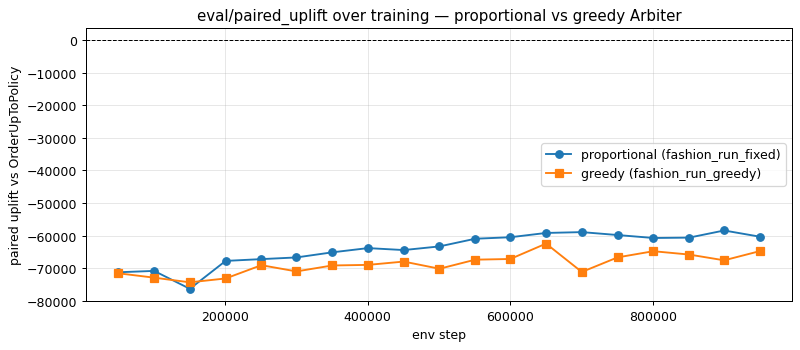

Greedy best checkpoint: actor_step0000650240.pt  (uplift=-62473.1)
  arbiter_mode recorded in bundle: greedy



Capacity-starved regime, 16 paired held-out CRN seeds:


,proportional,greedy,OrderUpToPolicy
mean return,91443.984,84914.549,128973.030
mean uplift vs baseline,-37529.046,-44058.481,0.000
win rate vs baseline,0.000,0.000,NaN
mean stockout rate,0.176,0.135,0.244


In [9]:
# --- Load the greedy-arbiter run: runs/fashion_run_greedy -------------------
greedy_run_dir = RUN_ROOT / 'fashion_run_greedy'
assert greedy_run_dir.exists(), (
    'Greedy run missing — train it with:\n'
    '  uv run python -m src.rl.train --total-env-steps 1000000 --n-envs 8 '
    '--experiment-name fashion_run_greedy --arbiter-mode greedy '
    '--setup-dir setups/fashion_retail'
)

# Learning-curve overlay: both runs share the same held-out CRN eval seeds,
# so the two uplift curves are directly comparable point by point.
def uplift_series(rd):
    ev = sorted(rd.glob('events.out.tfevents.*'))[0]
    acc = EventAccumulator(str(ev))
    acc.Reload()
    evs = acc.Scalars('eval/paired_uplift')
    return [e.step for e in evs], [e.value for e in evs]

steps_prop, up_prop = uplift_series(run_dir)
steps_grd,  up_grd  = uplift_series(greedy_run_dir)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps_prop, up_prop, marker='o', label='proportional (fashion_run_fixed)')
ax.plot(steps_grd,  up_grd,  marker='s', label='greedy (fashion_run_greedy)')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('eval/paired_uplift over training — proportional vs greedy Arbiter')
ax.set_xlabel('env step'); ax.set_ylabel('paired uplift vs OrderUpToPolicy')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Best greedy checkpoint by its own eval/paired_uplift (same rule as section 2).
greedy_ckpts = sorted((greedy_run_dir / 'checkpoints').glob('actor_step*.pt'))
best_g_idx = int(np.argmax(up_grd))
matching = [p for p in greedy_ckpts if str(steps_grd[best_g_idx]) in p.stem]
best_greedy_ckpt = matching[0] if matching else greedy_ckpts[-1]

greedy_actor, greedy_bundle = load_actor(best_greedy_ckpt)
print(f'Greedy best checkpoint: {best_greedy_ckpt.name}  '
      f'(uplift={up_grd[best_g_idx]:+.1f})')
print(f"  arbiter_mode recorded in bundle: {greedy_bundle['config']['arbiter_mode']}")

def greedy_policy_fn(obs_flat: np.ndarray) -> np.ndarray:
    obs_2d = torch.tensor(obs_flat, dtype=torch.float32).reshape(1, K_MAX, F)
    mask   = obs_2d[..., ROW_MASK]
    with torch.no_grad():
        action, _, _ = greedy_actor.get_action_and_log_prob(obs_2d, mask)
    return action.squeeze(0).reshape(K_MAX * 3).numpy()

# Run the greedy model on the SAME capacity-starved CRN specs as section 5b,
# so all three columns below are paired on identical worlds.
greedy_rows = []
for i, spec in enumerate(starved_specs):
    m = evaluate(greedy_policy_fn, lambda: OrderUpToPolicy(), [spec], config=starved_cfg)
    greedy_rows.append({
        'seed': i,
        'rl_return': m['eval/rl_return'],
        'uplift': m['eval/paired_uplift'],
        'rl_stockout': m['eval/rl_stockout_rate'],
    })
greedy_df = pd.DataFrame(greedy_rows)

comparison = pd.DataFrame({
    'proportional': {
        'mean return': starved_df['rl_return'].mean(),
        'mean uplift vs baseline': starved_df['uplift'].mean(),
        'win rate vs baseline': (starved_df['uplift'] > 0).mean(),
        'mean stockout rate': starved_df['rl_stockout'].mean(),
    },
    'greedy': {
        'mean return': greedy_df['rl_return'].mean(),
        'mean uplift vs baseline': greedy_df['uplift'].mean(),
        'win rate vs baseline': (greedy_df['uplift'] > 0).mean(),
        'mean stockout rate': greedy_df['rl_stockout'].mean(),
    },
    'OrderUpToPolicy': {
        'mean return': starved_df['baseline_return'].mean(),
        'mean uplift vs baseline': 0.0,
        'win rate vs baseline': float('nan'),
        'mean stockout rate': starved_df['bl_stockout'].mean(),
    },
})
print(f'\nCapacity-starved regime, {len(starved_specs)} paired held-out CRN seeds:')
display(comparison.round(3))

## 6 · Implicit assortment demo

The policy has no explicit assortment-selection head. "Stop carrying a product" is
expressed through the **order-up-to head** (action column 1): holding a product's target
at the bottom of the range means it is never restocked and sells down to zero. The action
layout (`src/rl/set_encoder.py`) is:

| Column | Head | Decodes to |
|---|---|---|
| 0 | price | `[0.5, 1.5] × MSRP` |
| 1 | order-up-to target | lead-time units via the order-up-to decoder |
| 2 | priority | product ranking, used **only by the greedy Arbiter** |

> **Caveat — the price head is currently inert.** The engine's demand-pull walk
> (`src/sim/runner.py`) applies only `action["order"]` for intermediate nodes; the
> decoded `list_price` / `min_order_imposed` values are never written to the node
> (factories do get their prices applied). So the price head — and any "stop carrying
> via pricing" story — has no effect on dynamics today, in training or eval alike. This
> section shows what the heads *output*, not realised prices. Tracked as issue
> `02-intermediate-list-price-action-never-applied` under `.scratch/rl-eval-followups/`.

We inspect the **deterministic policy means** (not a stochastic sample) for one live
observation to show which products the policy chooses to restock and at what price point.

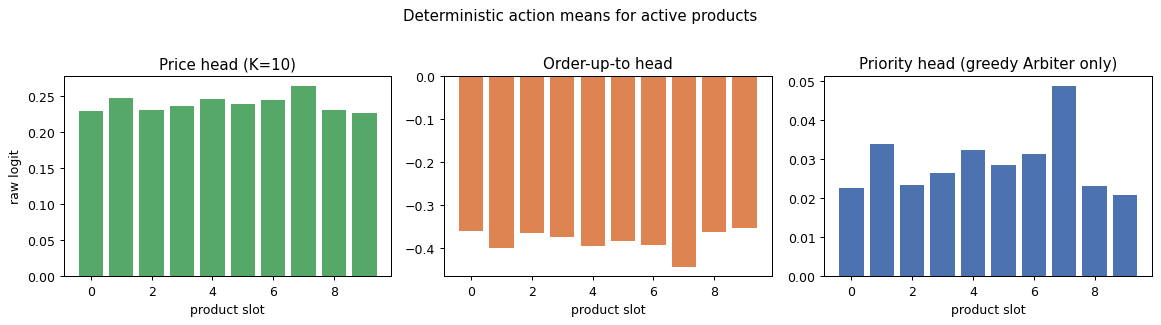

Implicit assortment (order-up-to head, highest target first):
  rank 1: product slot 9  order-up-to logit=-0.355
  rank 2: product slot 0  order-up-to logit=-0.362
  rank 3: product slot 8  order-up-to logit=-0.363
  rank 4: product slot 2  order-up-to logit=-0.364
  rank 5: product slot 3  order-up-to logit=-0.376
  rank 6: product slot 5  order-up-to logit=-0.383
  rank 7: product slot 6  order-up-to logit=-0.393
  rank 8: product slot 4  order-up-to logit=-0.396
  rank 9: product slot 1  order-up-to logit=-0.401
  rank 10: product slot 7  order-up-to logit=-0.444


In [10]:
obs_flat_live, info = RLEnv(catalog=catalog, config=cfg, market_params=market).reset(seed=42)
obs_2d_live = obs_flat_live.reshape(K_MAX, F)
mask_col = obs_2d_live[:, ROW_MASK]
k_active_live = int(mask_col.sum())

obs_t_live = torch.tensor(obs_2d_live, dtype=torch.float32).unsqueeze(0)
mask_t_live = torch.tensor(mask_col, dtype=torch.float32).unsqueeze(0)

# Deterministic policy output: the tanh-squashed means of the action
# distribution, not a stochastic sample.
with torch.no_grad():
    mean_live = best_actor.get_distribution(obs_t_live, mask_t_live).mean
mean_live = mean_live.squeeze(0).numpy()  # (K_MAX, 3)

price_logits    = mean_live[:k_active_live, 0]
order_logits    = mean_live[:k_active_live, 1]
priority_scores = mean_live[:k_active_live, 2]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
x = np.arange(k_active_live)
axes[0].bar(x, price_logits, color='#55A868')
axes[0].set_title(f'Price head (K={k_active_live})')
axes[0].set_xlabel('product slot'); axes[0].set_ylabel('raw logit')

axes[1].bar(x, order_logits, color='#DD8452')
axes[1].set_title('Order-up-to head'); axes[1].set_xlabel('product slot')

axes[2].bar(x, priority_scores, color='#4C72B0')
axes[2].set_title('Priority head (greedy Arbiter only)'); axes[2].set_xlabel('product slot')

plt.suptitle('Deterministic action means for active products', y=1.02)
plt.tight_layout(); plt.show()

rank = np.argsort(-order_logits)
print('Implicit assortment (order-up-to head, highest target first):')
for pos, slot in enumerate(rank):
    print(f'  rank {pos+1}: product slot {slot}  order-up-to logit={order_logits[slot]:+.3f}')

## 7 · Permutation equivariance check

Because `SetActor` applies the **same per-row MLP** to every row, permuting the rows of
the input should permute the rows of the output in the same way (up to floating-point
precision). We compare the **deterministic distribution means** — sampled actions draw
independent Gaussian noise per call, so comparing two samples would always mismatch
regardless of the architecture. We shuffle the active rows and confirm
`mean[perm[i]] ≈ mean_permuted[i]`.

In [11]:
obs_2d_perm = obs_2d_live.copy()
perm = list(np.random.default_rng(0).permutation(k_active_live)) + list(range(k_active_live, K_MAX))
perm = np.array(perm)
obs_2d_perm_sorted = obs_2d_perm[perm]

obs_t_perm = torch.tensor(obs_2d_perm_sorted, dtype=torch.float32).unsqueeze(0)
mask_t_perm = torch.tensor(obs_2d_perm_sorted[:, ROW_MASK], dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    mean_perm = best_actor.get_distribution(obs_t_perm, mask_t_perm).mean
mean_perm = mean_perm.squeeze(0).numpy()

# mean_live[perm[i]] should equal mean_perm[i] for active rows
max_diff = 0.0
for new_pos, old_pos in enumerate(perm[:k_active_live]):
    diff = np.abs(mean_live[old_pos] - mean_perm[new_pos]).max()
    max_diff = max(max_diff, diff)
    if diff > 1e-5:
        print(f'  MISMATCH at new_pos={new_pos} old_pos={old_pos}: max_diff={diff:.2e}')

print(f'Max element-wise difference across {k_active_live} active product rows: {max_diff:.2e}')
if max_diff < 1e-5:
    print('Permutation equivariance confirmed (diff < 1e-5).')
else:
    print('WARNING: permutation equivariance violated! Check SetActor implementation.')

Max element-wise difference across 10 active product rows: 0.00e+00
Permutation equivariance confirmed (diff < 1e-5).


## Summary

We have demonstrated on these runs:

- `checkpoint.load()` validates `layout_version` before building the actor, giving a
  clean error on stale checkpoints. The bundle also records the `arbiter_mode` the
  policy was trained under.
- The same `SetActor` weights handle any K from 1 to `K_MAX` without retraining —
  structural permutation invariance via the shared-weight per-row MLP.
- CRN-paired evaluation (same world seed, capacity, balance, active_subset,
  allocation_sub_seed) isolates policy quality from noise — which is also why the
  baseline eval curve is perfectly flat over training (section 2).
- **In the capacity-starved regime (K∈[15,20], capacity∈[100,150]) both trained agents
  lose to `OrderUpToPolicy` on net profit on every one of the 16 held-out seeds**
  (section 5b/5c): mean uplift −37.5 k (proportional) and −44.1 k (greedy) against a
  baseline mean return of 128 973 vs 91 444 / 84 915 for the agents. Both agents do
  achieve lower stockout rates (0.176 / 0.135 vs 0.244) — they spread orders more
  evenly across SKUs — but at this 1 M-step budget that does not convert into profit.
  Across the full domain-randomisation range (capacity up to 10 000) the baseline wins
  as well: when capacity is loose, per-SKU order-up-to is near-optimal, and the uplift
  curve was still climbing when training stopped.
- **Why earlier numbers looked much better**: the pre-rebuild eval harness ran the RL
  arm without the Arbiter, and per-SKU decode caps plus an engine clamp that ignores
  in-transit stock let the RL node hold 10–16× its capacity (section 5b). The current
  harness applies the Arbiter inside `RLNodePolicy.decide()` — the same dynamics as
  training — so these are the honest numbers.
- **Arbiter comparison** (section 5c): the greedy-trained agent trails proportional in
  the contention regime too (mean uplift −44.1 k vs −37.5 k), though it posts the lowest
  stockout rate of the three policies (0.135). The Arbiter is part of the training
  dynamics, so each mode needs its own training run: under `proportional` the priority
  head gets no learning signal.
- The order-up-to head implicitly selects assortment: products whose target is held
  low are never restocked and sell down to zero. The priority head only matters under
  the greedy Arbiter. (The price head is currently inert engine-side — see the section 6
  caveat.)
- Permuting input rows permutes the actor's distribution means in kind — the policy is
  genuinely permutation-equivariant.
- **Train/eval parity** (section 8): `RLNodePolicy.from_checkpoint` wraps the trained
  checkpoint as a standard `IntermediatePolicy` so it can be attached to any node via
  `Runner(scenario, policy_overrides={...}).run()`. The Arbiter travels inside the policy,
  applying the same reconciliation logic at eval and deployment as during training. The
  resulting `run_log` is identical in structure to any other `Runner` run, so the full
  suite of `inspect` + `metrics` tools works out of the box.

For the recommended training budget and CLI flags, see `src/rl/README.md`.

## 8 · Attach-and-run demo

`RLNodePolicy.from_checkpoint` wraps the trained `SetActor` as a standard
`IntermediatePolicy`, so it attaches to any `IntermediateNode` via the same
`Runner(scenario, policy_overrides={...}).run()` API used for textbook policies
(see [`src/tuning/README.md`](../src/tuning/README.md) for the tuning counterpart).
The Arbiter travels inside the policy — same code path as training.

### 8a · In-distribution: best proportional checkpoint on the training topology

We attach the best `fashion_run_fixed` checkpoint to the single trainable node `"S"` —
the same degenerate 3-node graph the agent trained on. This is the cleanest
"does it work end-to-end?" check. We then analyse the resulting `run_log` with the
standard `inspect` + `metrics` DataFrame builders, confirming the run log is identical
in structure to any other `Runner` run.

Run log keys: ['n_steps', 'ticks', 'global']
n_steps: 180
flow_frame shape: (8100, 7)
business_metrics (system row):


,node_id,service_level,stockout_rate,inventory_turnover,mean_price_pct_of_msrp
0,F_P0018,1.0,0.0,0.013,0.343


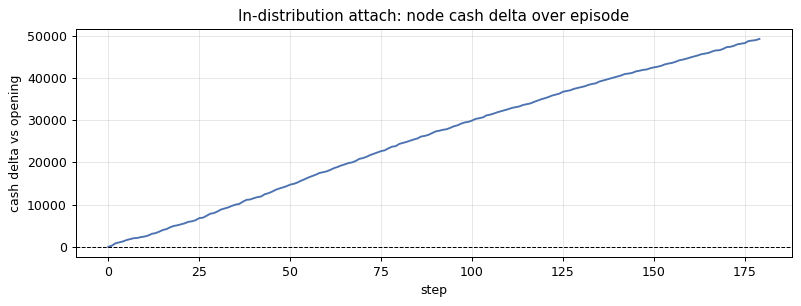

Opening cash: 887129
Closing cash: 936426  (delta: +49297)

In-distribution attach: run_log produced and analysed with standard inspect/metrics tooling.


In [12]:
from src.rl.node_policy import RLNodePolicy
from src.sim.runner import Runner
from src.sim import inspect as sim_inspect
from src.sim.metrics import business_metrics

# Reuse one of the held-out CRN specs — it has .scenario already built.
spec_attach = starved_specs[0]
scenario_attach = spec_attach.scenario

# One fresh RLNodePolicy per run — stateful, no reset().
attach_policy = RLNodePolicy.from_checkpoint(str(best_ckpt))

runner_attach = Runner(scenario_attach, policy_overrides={"S": attach_policy})
run_log_attach = runner_attach.run()

print(f"Run log keys: {list(run_log_attach.keys())}")
print(f"n_steps: {run_log_attach['n_steps']}")

# The run_log is identical in structure to any textbook-policy run.
flow_attach = sim_inspect.flow_frame(run_log_attach)
ts_attach = sim_inspect.node_timeseries_df(run_log_attach, scenario_attach)
bm_attach = business_metrics(flow_attach, ts_attach, scenario_attach)
print(f"flow_frame shape: {flow_attach.shape}")
print("business_metrics (system row):")
bm_sys = bm_attach[bm_attach['node_id'] == '__system__'] if '__system__' in bm_attach['node_id'].values else bm_attach.head(1)
display(bm_sys.round(3))

# Cumulative cash delta over the episode (policy's net profit proxy)
node_cash_attach = [tick['node_cash'].get('S', 0) for tick in run_log_attach['ticks']]
opening_cash_attach = node_cash_attach[0] if node_cash_attach else 0
cum_profit_attach = [c - opening_cash_attach for c in node_cash_attach]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(cum_profit_attach, color='#4C72B0')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('In-distribution attach: node cash delta over episode')
ax.set_xlabel('step'); ax.set_ylabel('cash delta vs opening'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Opening cash: {opening_cash_attach:.0f}")
print(f"Closing cash: {node_cash_attach[-1]:.0f}  (delta: {cum_profit_attach[-1]:+.0f})")
print("\nIn-distribution attach: run_log produced and analysed with standard inspect/metrics tooling.")

### 8b · Attach again on a second world

The same checkpoint, attached via the identical recipe to node `"S"` on a *different*
held-out spec — a new episode world on the same degenerate training topology. This
re-confirms the attach API composes with any Runner-compatible scenario; it is **not** a
transfer or generalisation demo (a true deeper-topology OOD attach would need a
multi-echelon scenario, which this notebook does not build).

> **Caveat.** Do not interpret the numbers below as a quality signal — this cell only
> verifies the API works on a fresh scenario object. Attaching the checkpoint to a node
> in a genuinely deeper graph (longer lead times, different upstream supply dynamics)
> would carry no transfer guarantee either; the policy was trained on the single-node
> degenerate graph.

In [13]:
# Reuse a *different* spec to get a different episode world for the OOD demo.
spec_ood = starved_specs[1]
scenario_ood = spec_ood.scenario   # same degenerate topology — illustrates API re-use on a
                                    # new world rather than a true deeper graph, while staying
                                    # within the notebook's existing setup.

# Fresh policy instance (required — no reset()).
ood_policy = RLNodePolicy.from_checkpoint(str(best_ckpt))
runner_ood = Runner(scenario_ood, policy_overrides={"S": ood_policy})

try:
    run_log_ood = runner_ood.run()
    node_cash_ood = [tick['node_cash'].get('S', 0) for tick in run_log_ood['ticks']]
    flow_ood = sim_inspect.flow_frame(run_log_ood)
    print(f"OOD spec attach: run_log produced, {run_log_ood['n_steps']} steps")
    print(f"  final cash: {node_cash_ood[-1]:.0f}  "
          f"  flow_frame rows: {len(flow_ood)}")
    print()
    print("The attach API composes with any Runner-compatible scenario.")
    print("Numbers are NOT a transfer-performance signal — see OOD caveat above.")
except Exception as e:
    print(f"OOD attach raised: {e}")

OOD spec attach: run_log produced, 180 steps
  final cash: 623508    flow_frame rows: 8640

The attach API composes with any Runner-compatible scenario.
Numbers are NOT a transfer-performance signal — see OOD caveat above.
